In [1]:
from tem_dataset import TEMTrainDataset, TEMTestDataset, TEMPatchDataset


In [ ]:
train_path = "/home/minq02/github/TEMCellSegmentation/data/train/train_data.h5"
test_path  = "/home/minq02/github/TEMCellSegmentation/data/test/test_data.h5"

train_ds = TEMTrainDataset(train_path)
test_ds  = TEMTestDataset(test_path)

print("Train length:", len(train_ds))
print("Test length:", len(test_ds))


In [ ]:
for i in range(len(train_ds)):
    img0, mask0 = train_ds[i]
    print(f"Type and shape of train sample {i}:")
    print(type(img0), img0.shape)
    print(type(mask0), mask0.shape)

In [ ]:
test_item = test_ds[0]
print(len(test_item), [type(x) for x in test_item])
print(test_item[0].shape)   # image shape
print(test_item[0])         # key / id

img, k = test_item[1]
print(type(img), img)
print(type(k), k)

In [ ]:
import h5py
import numpy as np

train_h5 = "/home/minq02/github/TEMCellSegmentation/data/train/train_data.h5"
test_h5  = "/home/minq02/github/TEMCellSegmentation/data/test/test_data.h5"

with h5py.File(train_h5, "r") as f:
    print("Top-level groups:", list(f.keys()))
    print("Number of raw images:", len(f["raw"]))
    print("Number of label masks:", len(f["label"]))

    k0 = list(f["raw"].keys())[0]
    raw0 = f["raw"][k0][()]
    lab0 = f["label"][k0][()]

    print("Example key:", k0)
    print("raw0 shape:", raw0.shape, raw0.dtype)
    print("lab0 shape:", lab0.shape, lab0.dtype)
    print("unique labels:", np.unique(lab0))


In [ ]:
with h5py.File(test_h5, "r") as f:
    print("Top-level groups:", list(f.keys()))
    print("Number of raw images:", len(f["raw"]))

    k0 = list(f["raw"].keys())[0]
    raw0 = f["raw"][k0][()]

    print("Example key:", k0)
    print("raw0 shape:", raw0.shape, raw0.dtype)

[TEMPatchDataset] 2269 patches from 11 images
Number of patches: 2269
Img shape: torch.Size([512, 512]) dtype: torch.float32
Mask shape: torch.Size([512, 512]) dtype: torch.int64
Unique labels in this patch: tensor([0, 2, 3, 4])
Batch imgs shape: torch.Size([4, 512, 512])
Batch masks shape: torch.Size([4, 512, 512])


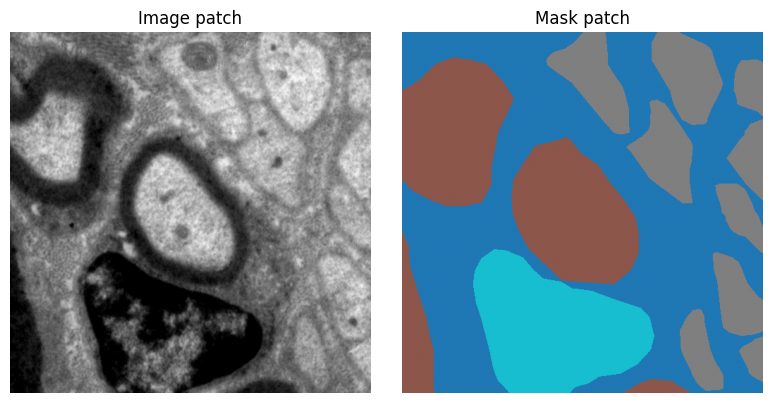

In [7]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# 1. Create dataset
h5_path = "/home/minq02/github/TEMCellSegmentation/data/train/train_data.h5"
patch_size = 512

train_patches = TEMPatchDataset(
    h5_path=h5_path,
    patch_size=patch_size,
    stride=patch_size,  # non-overlapping
)

print(f"Number of patches: {len(train_patches)}")

# 2. Inspect a single sample
img, mask = train_patches[1192]
print("Img shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype)
print("Unique labels in this patch:", torch.unique(mask))

# 3. Quick dataloader + batch shape check
loader = DataLoader(train_patches, batch_size=4, shuffle=True)

batch_imgs, batch_masks = next(iter(loader))
print("Batch imgs shape:", batch_imgs.shape)   # (B, H, W)
print("Batch masks shape:", batch_masks.shape) # (B, H, W)

# 4. Visualize one patch + its mask
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Image patch")
plt.imshow(img.numpy(), cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mask patch")
plt.imshow(mask.numpy(), cmap="tab10")
plt.axis("off")

plt.tight_layout()
plt.show()
